# Cross-Validated PC Predictions
Setup environment

In [2]:
import numpy as np
from itertools import combinations

n_repeats = 32
n_maps = 32
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
pairs = combinations(np.arange(n_players), 2)
n_pcs = 142

datadir = '/jukebox/hasson/snastase/social-ctf/results'

Read in LSTM data. 
lstms has shape 32 maps, 32 repeats, 4501 samples, 4 players, 142 PCs. lstms_stack collapses this to 32*32*4501 samples, 4 players, and 142 PCs.

In [3]:
from scipy.stats import zscore

# data shape = (2 repeats, 4 players, 4501 samples, 142 PCs)
lstms = np.full((n_maps, n_repeats, n_samples, n_players, n_pcs), np.nan, dtype='uint8')
map_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy')
        lstms[map_id, repeat_id] = zscore(np.moveaxis(data[..., :n_pcs], 0, 1), axis=0)
        map_ids.extend([map_id]*n_samples)
    print(f'Finished loading {map_id}')
print(f'LSTMs shape: {lstms.shape}')

KeyboardInterrupt: 

In [15]:
from scipy.stats import zscore

# data shape = (2 repeats, 4 players, 4501 samples, 142 PCs)
lstms = np.full((n_maps, n_repeats, n_samples, n_players, n_pcs), np.nan, dtype='uint8')
map_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        map_ids.extend([map_id]*n_samples)

In [12]:
lstms_stack = np.dstack(np.split(lstms, n_repeats, axis=1)).squeeze() #32 x 144032 x 2
lstms_stack = np.hstack(np.split(lstms_stack, n_maps, axis=0)).squeeze()
print(f'LSTMs stack shape: {lstms_stack.shape}')

LSTMs stack shape: (4609024, 4, 142)


In [13]:
np.save('lstms_stack.npy', lstms_stack)

In [3]:
lstms_stack = np.load('lstms_stack.npy')

In [144]:
len(map_ids)

4609024

Perform an ISC regression for each PC and pair. results is of shape 142 PCs, 6 pairs, 1024 folds (32 maps * 32 repeats)

In [101]:
from sklearn.model_selection import PredefinedSplit
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
cv = PredefinedSplit(map_ids)

coefs = np.full((n_pcs, int(n_pairs), n_maps*n_repeats), np.nan)
results = np.full((n_pcs, int(n_pairs), n_maps), np.nan)  #n_repeats
for pc_id in np.arange(n_pcs):
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        ##coef = []
        for fold, (train, test) in enumerate(cv.split()):
            reg = LinearRegression()
            reg.fit(lstms_stack[train, pair[0], pc_id][:, np.newaxis], 
                    lstms_stack[train, pair[1], pc_id])
            #if pc_id==1:
            #    raise
            coefs[pc_id, pair_id, fold] = reg.coef_
            ##coef.extend([reg.coef_ for i in range(n_repeats)])
            pred = reg.predict(lstms_stack[test, pair[0], pc_id][:, np.newaxis])
            result.extend([pearsonr(p, t)[0] for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(lstms_stack[test, pair[1], pc_id], n_repeats, axis=0))])
        print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}
        results[pc_id, pair_id] = np.array(result)
        ##coefs[pc_id, pair_id] = np.array(coef)

Finished ISC regression for PC 0, pair 0
Finished ISC regression for PC 0, pair 1
Finished ISC regression for PC 0, pair 2
Finished ISC regression for PC 0, pair 3
Finished ISC regression for PC 0, pair 4
Finished ISC regression for PC 0, pair 5
Finished ISC regression for PC 1, pair 0
Finished ISC regression for PC 1, pair 1
Finished ISC regression for PC 1, pair 2
Finished ISC regression for PC 1, pair 3
Finished ISC regression for PC 1, pair 4
Finished ISC regression for PC 1, pair 5
Finished ISC regression for PC 2, pair 0
Finished ISC regression for PC 2, pair 1
Finished ISC regression for PC 2, pair 2
Finished ISC regression for PC 2, pair 3
Finished ISC regression for PC 2, pair 4
Finished ISC regression for PC 2, pair 5
Finished ISC regression for PC 3, pair 0
Finished ISC regression for PC 3, pair 1
Finished ISC regression for PC 3, pair 2
Finished ISC regression for PC 3, pair 3
Finished ISC regression for PC 3, pair 4
Finished ISC regression for PC 3, pair 5
Finished ISC reg

In [ ]:
from sklearn.model_selection import PredefinedSplit
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
cv = PredefinedSplit(map_ids)

coefs = np.full((n_pcs, int(n_pairs), n_maps*n_repeats), np.nan)
results = np.full((n_pcs, int(n_pairs), n_maps), np.nan)
for pc_id in np.arange(2):
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        for fold, (train, test) in enumerate(cv.split()):
            reg = LinearRegression()
            reg.fit(lstms_stack[train, pair[0], pc_id][:, np.newaxis], 
                    lstms_stack[train, pair[1], pc_id])
            #if pc_id==1:
            #    raise
            #print(pc_id, pair_id, fold, reg.coef_)
            coefs[pc_id, pair_id, fold] = reg.coef_
            pred = reg.predict(lstms_stack[test, pair[0], pc_id][:, np.newaxis])
            #result.extend([pearsonr(p, t)[0] for p, t in
            #               zip(np.split(pred, n_repeats, axis=0),
            #                   np.split(lstms_stack[test, pair[1], pc_id], n_repeats, axis=0))])
        print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}
        results[pc_id, pair_id] = np.array(result)

In [7]:
results.shape

(142, 6, 1024)

In [46]:
coefs.shape

(142, 6, 32)

In [40]:
coefs = coefs[:,:,:n_maps]

In [47]:
np.argwhere(np.isnan(coefs))#np.ndarray.tolist()[:,2])

array([], shape=(0, 3), dtype=int64)

In [118]:
pairs = combinations(np.arange(n_players), 2)
for i, x in enumerate(pairs):
    print(i,x)

0 (0, 1)
1 (0, 2)
2 (0, 3)
3 (1, 2)
4 (1, 3)
5 (2, 3)


In [41]:
np.save('cvISC_coefs.npy', coefs)

In [104]:
np.save('regression_results.npy', results)

In [8]:
results = np.load('regression_results.npy')

In [45]:
coefs = np.load('cvISC_coefs.npy')

Make a dataframe of cooperative and competitive ISCs

In [42]:
import pandas as pd

results_df_dict_full = {'PC': [], 'coop coef': [], 'comp coef': [], 'cooperative cvISC': [], 'competitive cvISC': [], 'cooperative-competitive cvISC difference': []}

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for pc_id in np.arange(n_pcs): 
    for map_id in np.arange(n_maps):
        for repeat_id in np.arange(n_repeats):
            game_id=map_id*n_repeats+repeat_id
            coop = np.mean(results[pc_id, coop_ids, game_id], axis=0)
            comp = np.mean(results[pc_id, comp_ids, game_id], axis=0)
            #if not np.isnan(coefs[pc_id, 5, game_id]):
            #print(coefs[pc_id, coop_ids, game_id])
            coop_coef = np.mean(coefs[pc_id, coop_ids, map_id], axis=0)
            comp_coef = np.mean(coefs[pc_id, comp_ids, map_id], axis=0)
            results_df_dict_full['cooperative cvISC'].append(coop)
            results_df_dict_full['competitive cvISC'].append(comp)
            results_df_dict_full['cooperative-competitive cvISC difference'].append(coop-comp)
            results_df_dict_full['PC'].append(pc_id + 1)
            results_df_dict_full['coop coef'].append(coop_coef)
            results_df_dict_full['comp coef'].append(comp_coef)

results_df_full = pd.DataFrame(results_df_dict_full)
results_df_full

,PC,coop coef,comp coef,cooperative cvISC,competitive cvISC,cooperative-competitive cvISC difference
0,1,-0.009346,-0.030464,-0.000558,-0.000288,-0.000270
1,1,-0.009346,-0.030464,0.022159,0.011377,0.010782
2,1,-0.009346,-0.030464,0.059278,0.072876,-0.013598
3,1,-0.009346,-0.030464,0.019093,0.019256,-0.000163
4,1,-0.009346,-0.030464,0.066834,0.016448,0.050386
...,...,...,...,...,...,...
145403,142,0.022855,0.009780,-0.008464,0.003550,-0.012013
145404,142,0.022855,0.009780,0.023937,0.019353,0.004585
145405,142,0.022855,0.009780,0.035792,0.037537,-0.001745
145406,142,0.022855,0.009780,0.041881,0.005123,0.036758


Plot cvISC for cooperative and competitive pairs for each PC

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

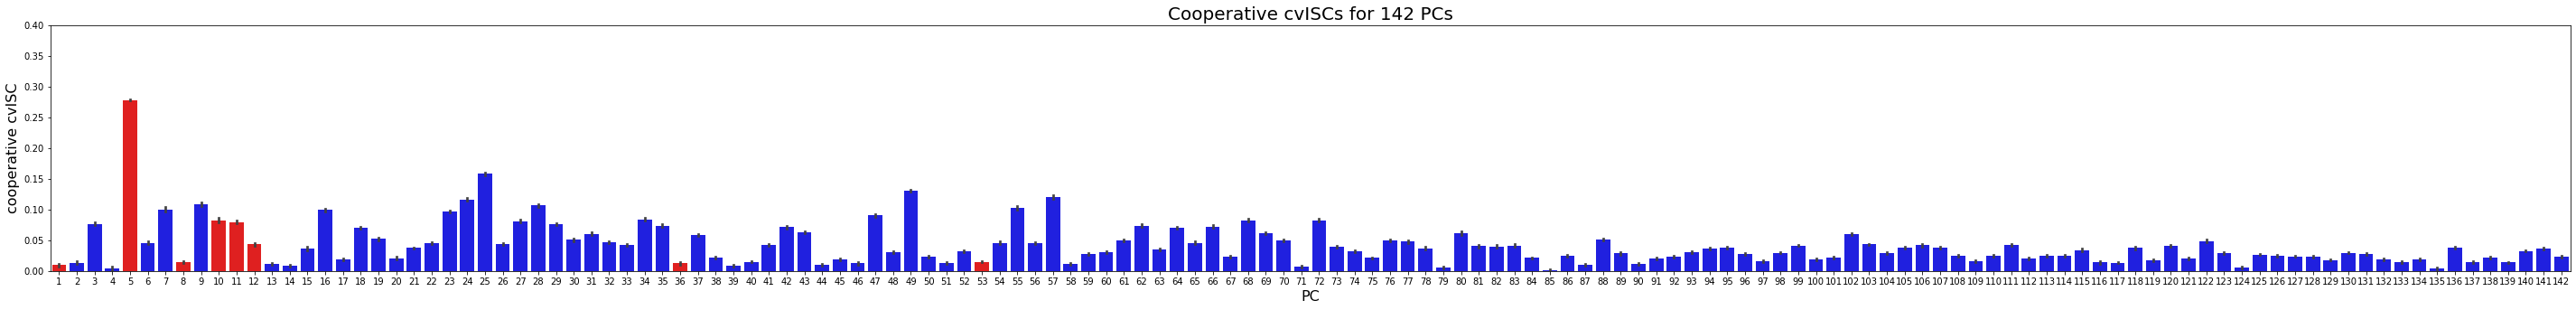

In [51]:
#cols = ['red' if np.mean(results_df_full[results_df_full['PC']==x]['cooperative cvISC']) < 
#        np.mean(results_df_full[results_df_full['PC']==x]['competitive cvISC']) 
#        else 'blue' for x in range(142)]
cols = ['red' if np.mean(results_df_full[results_df_full['PC']==x]['coop coef']) < 0
       else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='cooperative cvISC', data=results_df_full, palette=cols) #color='gray')
ax.set_ylim(0, .4) #was using .6?
ax.set_title('Cooperative cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('cooperative cvISC', fontsize=16);
fig.savefig("coop_cvISC.png")

In [34]:
results_df_full[results_df_full['PC']==1]['coop coef']

0      -0.009346
1      -0.009346
2      -0.009346
3      -0.009346
4      -0.009346
          ...   
1019   -0.009891
1020   -0.009891
1021   -0.009891
1022   -0.009891
1023   -0.009891
Name: coop coef, Length: 1024, dtype: float64

In [15]:
np.mean([np.nan, 5])<0

False

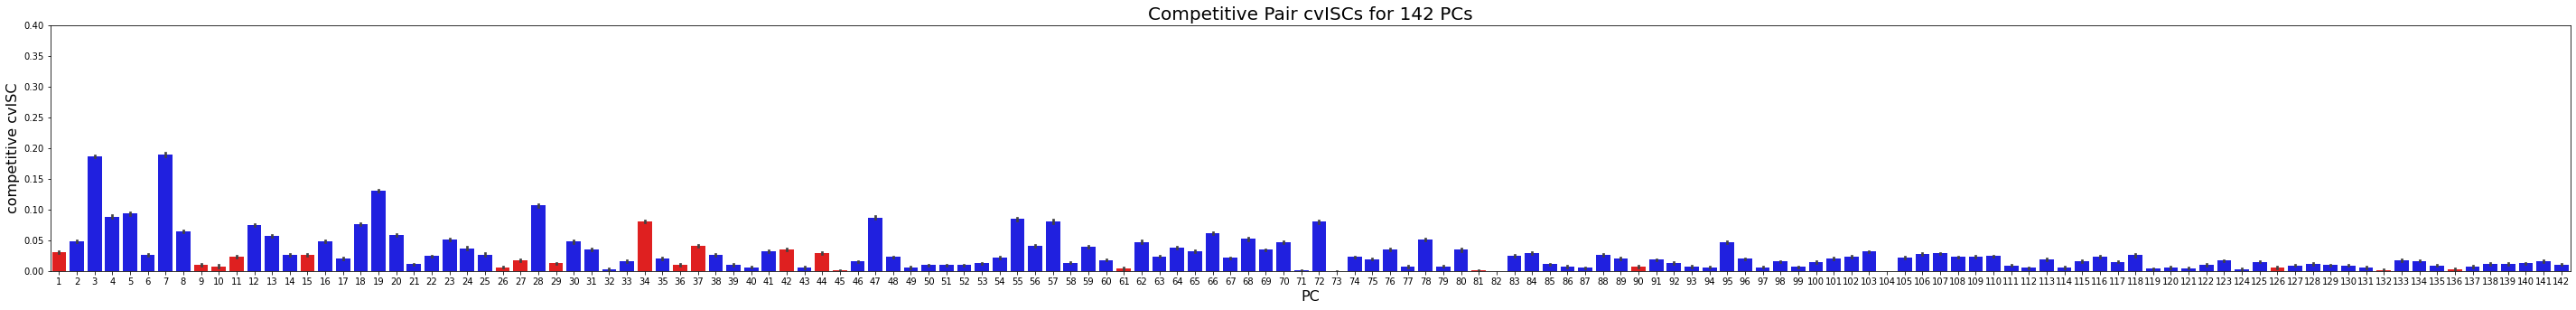

In [48]:
#cols = ['red' if np.mean(results_df_full[results_df_full['PC']==x]['cooperative cvISC']) < 
#        np.mean(results_df_full[results_df_full['PC']==x]['competitive cvISC']) 
#        else 'blue' for x in range(142)]
cols = ['red' if np.mean(results_df_full[results_df_full['PC']==x]['comp coef']) < 0
       else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='competitive cvISC', data=results_df_full, palette=cols)# color='gray')
ax.set_ylim(0, .4) #was using .6?
ax.set_title('Competitive Pair cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('competitive cvISC', fontsize=16);
fig.savefig("comp_cvISC.png")

### Wins and Score Prediction
Load wins and scores data

In [4]:
wins = np.load(f'/jukebox/hasson/snastase/social-ctf/results/wins_matchup-0.npy')
scores = np.load(f'/jukebox/hasson/snastase/social-ctf/results/scores_matchup-0.npy')

In [9]:
win_stack = np.hstack(np.split(wins, n_repeats, axis=0)).squeeze() #32 x 144032 x 2
print(f"Wins stack shape: {wins_stack.shape}")
score_stack = np.hstack(np.split(scores, n_repeats, axis=0)).squeeze() #32 x 144032 x 2
print(f"Scores stack shape: {scores_stack.shape}")

Wins stack shape: (1024, 2)
Scores stack shape: (1024, 2)


Predict wins using cvISC. results_wins is of shape 142 PCs, 2 teams, 32 folds

Fit a logistic regression for each fold to predict wins using cvISC. results_wins is of shape 142 PCs, 2 teams, 32 folds

In [13]:
from sklearn.model_selection import PredefinedSplit

# Create a new split over games (not samples)
map_ids_2 = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        map_ids_2.append(map_id)
        
cv2 = PredefinedSplit(map_ids_2)

In [60]:
###########################JUNK################################



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

results_wins = np.full((n_pcs, 2, n_maps), np.nan)   #n_repeats
coefs_wins = np.full((n_pcs, 2, n_maps), np.nan)   #n_repeats
for pc_id in np.arange(n_pcs):
    pairs = [(0, (0,1)), (5, (2,3))]
    for pair_id, pair in pairs:
        scores = []
        for f, (train, test) in enumerate(cv2.split()):
            # Initialize simple classifier
            clf = LogisticRegression(penalty='none', max_iter=300, class_weight='balanced') 

            # Z-score training SPIs and test SPIs (based on training set)
            results_train = zscore(results[pc_id, pair_id, train][:, np.newaxis]) 
            results_test = zscore(results[pc_id, pair_id, test][:, np.newaxis])

            # Train competitive/cooperative classifier based on train SPIs
            clf.fit(results_train, wins_stack[train, pair_id//5])

            # Use fitted classifier to predict test cooperative/competitive 
            pred = clf.predict(results_test)

            # Evaluate classifier accuracy
            score = accuracy_score(wins_stack[test, pair_id//5], pred)
            scores.append(score)
            
            
        results_wins[pc_id, pair_id//5] = np.array(scores)
    print(f"Finished wins regression for PC {pc_id}") 

Finished wins regression for PC 0
Finished wins regression for PC 1
Finished wins regression for PC 2
Finished wins regression for PC 3
Finished wins regression for PC 4
Finished wins regression for PC 5
Finished wins regression for PC 6
Finished wins regression for PC 7
Finished wins regression for PC 8
Finished wins regression for PC 9
Finished wins regression for PC 10
Finished wins regression for PC 11
Finished wins regression for PC 12
Finished wins regression for PC 13
Finished wins regression for PC 14
Finished wins regression for PC 15
Finished wins regression for PC 16
Finished wins regression for PC 17
Finished wins regression for PC 18
Finished wins regression for PC 19
Finished wins regression for PC 20
Finished wins regression for PC 21
Finished wins regression for PC 22
Finished wins regression for PC 23
Finished wins regression for PC 24
Finished wins regression for PC 25
Finished wins regression for PC 26
Finished wins regression for PC 27
Finished wins regression for P

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

teams = (0,5)
cvISC_stack = np.hstack((results[:, teams[0], :], results[:, teams[1], :]))#.squeeze()[:, np.newaxis]
print(cvISC_stack.shape)
wins_stack = np.concatenate((win_stack[:, 0], win_stack[:, 1]), axis=0)
print(wins_stack.shape)
cv3 = KFold(n_splits=32) 

results_wins = np.full((n_pcs, n_maps), np.nan)   #n_repeats
coefs_wins = np.full((n_pcs, n_maps), np.nan)   #n_repeats
for pc_id in np.arange(n_pcs):
    pairs = [(0,1),(2,3)]
    #for pair_id, pair in enumerate(pairs):
    #scores = []
    for f, (train, test) in enumerate(cv3.split(cvISC_stack[0])):#enumerate(cv2.split()):             
        # Initialize simple classifier
        clf = LogisticRegression(penalty='none', max_iter=300, class_weight='balanced') 

        # Z-score training and test cvISCs (based on training set)
        results_train = zscore(cvISC_stack[pc_id, train][:, np.newaxis])  #result, pair_id*5
        results_test = zscore(cvISC_stack[pc_id, test][:, np.newaxis])

        # Train logistic regression
        clf.fit(results_train, wins_stack[train])#, pair_id])

        # Predict test wins 
        pred = clf.predict(results_test)

        # Evaluate classifier accuracy
        score = accuracy_score(wins_stack[test], pred) #pair_id
        #scores.append(score)

        # Keep coefficient
        coefs_wins[pc_id, f] = clf.coef_ #pair_id
        results_wins[pc_id, f] = score #np.array(scores) #pair_id
    print(f"Finished wins regression for PC {pc_id}") 

In [25]:
results_wins.shape

(142, 32)

In [26]:
np.save('regression_wins_results_noPair.npy', results_wins)

In [27]:
np.save('regression_wins_coefs_noPair.npy', coefs_wins)

In [28]:
results_wins = np.load('regression_wins_results_noPair.npy')

In [29]:
coefs_wins = np.load('regression_wins_coefs_noPair.npy')

Make a dataframe of wins prediction accuracy for each PC

In [38]:
import pandas as pd

results_df_dict_wins = {'PC': [], 'wins coop': [], 'coef': []}

for pc_id in np.arange(n_pcs): 
    for game_id in np.arange(n_maps): #n_repeats
        wins_coop = results_wins[pc_id, game_id] #np.mean(results_wins[pc_id, (0,1), game_id], axis=0)
        coef = coefs_wins[pc_id, game_id]
        results_df_dict_wins['wins coop'].append(wins_coop)
        results_df_dict_wins['PC'].append(pc_id + 1)
        results_df_dict_wins['coef'].append(coef)

results_df_wins = pd.DataFrame(results_df_dict_wins)
results_df_wins

,PC,wins coop,coef
0,1,0.656250,0.179114
1,1,0.484375,0.196894
2,1,0.468750,0.200908
3,1,0.546875,0.178969
4,1,0.500000,0.200084
...,...,...,...
4539,142,0.593750,-0.071462
4540,142,0.562500,-0.088972
4541,142,0.515625,-0.095502
4542,142,0.484375,-0.092790


Plot wins prediction accuaracy

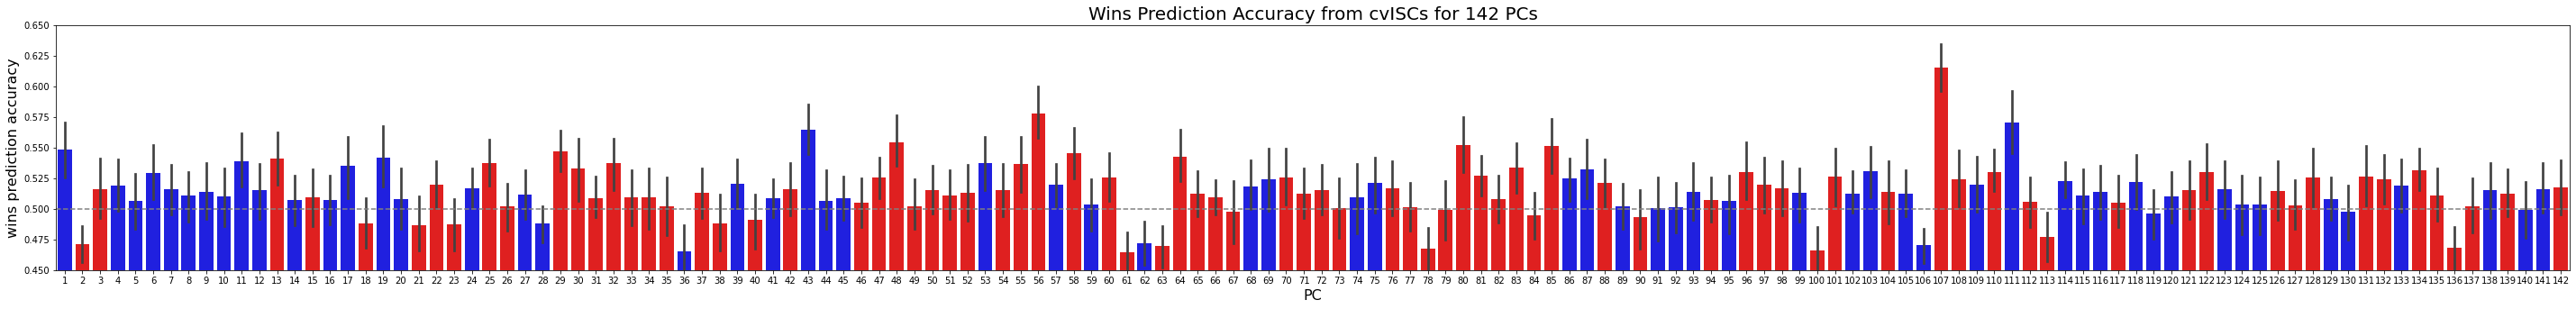

In [62]:
cols = ['red' if np.mean(results_df_wins[results_df_wins['PC']==x]['coef']) < 0
       else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='wins coop', data=results_df_wins, palette=cols) #color='gray')
ax.set_ylim(0.45, .65)
ax.set_title('Wins Prediction Accuracy from cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('wins prediction accuracy', fontsize=16);

# insert horizontal line (gray dotted) at 50
plt.axhline(y=.5, ls='--', c='gray')

Predict scores using cvISC. results_scores is of shape 142 PCs, 2 teams, 32 folds

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from scipy.stats import pearsonr

teams = (0,5)
cvISC_stack = np.hstack((results[:, teams[0], :], results[:, teams[1], :]))#.squeeze()[:, np.newaxis]
print(cvISC_stack.shape)
scores_stack = np.concatenate((score_stack[:, 0], score_stack[:, 1]), axis=0)
print(scores_stack.shape)
cv3 = KFold(n_splits=32) 

results_scores = np.full((n_pcs, n_maps), np.nan)   #n_repeats
coefs_scores = np.full((n_pcs, n_maps), np.nan)
for pc_id in np.arange(n_pcs):
    pairs = [(0, (0,1)), (5, (2,3))]
    #for pair_id, pair in pairs:
    #    scores = []
    for f, (train, test) in enumerate(cv3.split(cvISC_stack[0])):
        # Initialize simple classifier
        clf = LinearRegression() 

        # Z-score training and test cvISCs (based on training set)
        results_train = zscore(cvISC_stack[pc_id, train][:, np.newaxis]) 
        results_test = zscore(cvISC_stack[pc_id, test][:, np.newaxis])

        # Train linear regression
        clf.fit(results_train, scores_stack[train])

        # Predict test wins 
        pred = clf.predict(results_test)

        # Evaluate classifier accuracy
        r = pearsonr(pred, scores_stack[test])[0]
        #scores.append(r)

        # Keep coefficient
        coefs_scores[pc_id, f] = clf.coef_  #pair_id//5
        results_scores[pc_id, f] = r #np.array(scores)
    print(f"Finished scores regression for PC {pc_id}") 

(142, 2048)
(2048,)
Finished scores regression for PC 0
Finished scores regression for PC 1
Finished scores regression for PC 2
Finished scores regression for PC 3
Finished scores regression for PC 4
Finished scores regression for PC 5
Finished scores regression for PC 6
Finished scores regression for PC 7
Finished scores regression for PC 8
Finished scores regression for PC 9
Finished scores regression for PC 10
Finished scores regression for PC 11
Finished scores regression for PC 12
Finished scores regression for PC 13
Finished scores regression for PC 14
Finished scores regression for PC 15
Finished scores regression for PC 16
Finished scores regression for PC 17
Finished scores regression for PC 18
Finished scores regression for PC 19
Finished scores regression for PC 20
Finished scores regression for PC 21
Finished scores regression for PC 22
Finished scores regression for PC 23
Finished scores regression for PC 24
Finished scores regression for PC 25
Finished scores regression f

In [32]:
np.save('regression_scores_results_noPair.npy', results_scores)

In [33]:
np.save('regression_scores_coefs_noPair.npy', coefs_scores)

In [34]:
results_scores = np.load('regression_scores_results_noPair.npy')

In [35]:
coefs_scores = np.load('regression_scores_coefs_noPair.npy')

In [36]:
results_scores.shape

(142, 32)

Load results into a dataframe and plot

In [49]:
results_df_dict_scores = {'PC': [], 'scores coop': [], 'coef': []}# 'score diffs coop': [],, 'score diffs comp': []} #'wins comp': [],

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for pc_id in np.arange(n_pcs): 
    for game_id in np.arange(n_maps):# * n_repeats):
        #scores_coop_diffs = np.mean(results_scores_diffs[pc_id])
        scores_coop = results_scores[pc_id, game_id]
        coef = coefs_scores[pc_id, game_id]
        #results_df_dict_scores['score diffs coop'].append(scores_coop_diffs)
        results_df_dict_scores['scores coop'].append(scores_coop)
        results_df_dict_scores['PC'].append(pc_id + 1)
        results_df_dict_scores['coef'].append(coef)

results_df_scores = pd.DataFrame(results_df_dict_scores)
results_df_scores

,PC,scores coop,coef
0,1,0.128442,0.095933
1,1,-0.111011,0.112801
2,1,0.161727,0.087735
3,1,0.065056,0.101368
4,1,-0.142482,0.111880
...,...,...,...
4539,142,0.111184,-0.115253
4540,142,-0.049959,-0.129009
4541,142,-0.039030,-0.125187
4542,142,0.090313,-0.112688


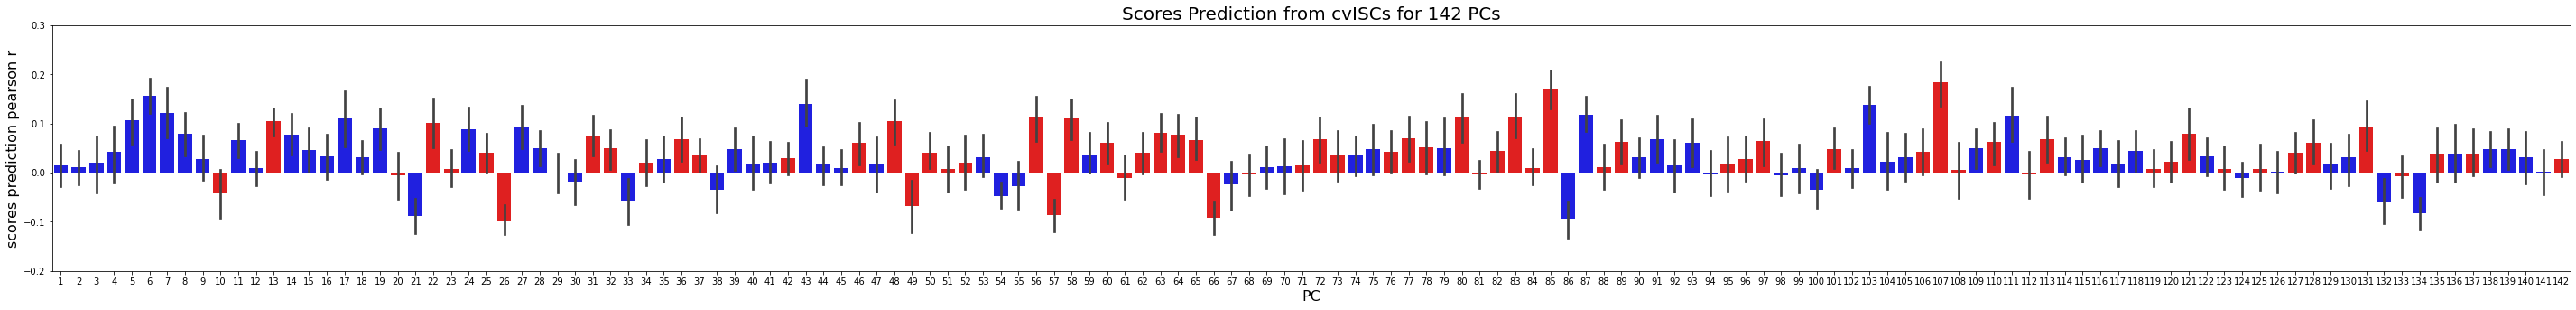

In [50]:
cols = ['red' if np.mean(results_df_scores[results_df_scores['PC']==x]['coef']) < 0
       else 'blue' for x in range(1,143)]
#cols = ['red' if np.mean(results_df_scores_diff[results_df_scores_diff['PC']==x]['scores diff coop']) < 0 else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='scores coop', data=results_df_scores, palette=cols)#color='gray')
ax.set_ylim(-.2, .3)
ax.set_title('Scores Prediction from cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('scores prediction pearson r', fontsize=16);

Predict score differences using cvISC. results_scores_diff is of shape 142 PCs, 32 folds

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from scipy.stats import pearsonr

results_scores_diff = np.full((n_pcs, n_maps), np.nan)   #n_repeats
coefs_scores_diff = np.full((n_pcs, n_maps), np.nan)
for pc_id in np.arange(n_pcs):
    scores = []
    for f, (train, test) in enumerate(cv2.split()):
        # Initialize simple classifier
        clf = LinearRegression() 

        # Z-score training and test cvISCs (based on training set)
        results_train = zscore((results[pc_id, 0, train]-results[pc_id, 5, train])[:, np.newaxis]) 
        results_test = zscore((results[pc_id, 0, test]-results[pc_id, 5, test])[:, np.newaxis])

        # Train logistic regression
        clf.fit(results_train, scores_stack[train, 0]-scores_stack[train, 1])

        # Predict test wins 
        pred = clf.predict(results_test)

        # Evaluate classifier accuracy
        r = pearsonr(pred, scores_stack[test, 0]-scores_stack[test, 1])[0]
        scores.append(r)
        
        # Keep coefficient
        coefs_scores_diff[pc_id, f] = clf.coef_
    results_scores_diff[pc_id] = np.array(scores)
    print(f"Finished scores regression for PC {pc_id}") 
print(f"Shape of results: {results_scores_diff.shape}") 

Finished scores regression for PC 0
Finished scores regression for PC 1
Finished scores regression for PC 2
Finished scores regression for PC 3
Finished scores regression for PC 4
Finished scores regression for PC 5
Finished scores regression for PC 6
Finished scores regression for PC 7
Finished scores regression for PC 8
Finished scores regression for PC 9
Finished scores regression for PC 10
Finished scores regression for PC 11
Finished scores regression for PC 12
Finished scores regression for PC 13
Finished scores regression for PC 14
Finished scores regression for PC 15
Finished scores regression for PC 16
Finished scores regression for PC 17
Finished scores regression for PC 18
Finished scores regression for PC 19
Finished scores regression for PC 20
Finished scores regression for PC 21
Finished scores regression for PC 22
Finished scores regression for PC 23
Finished scores regression for PC 24
Finished scores regression for PC 25
Finished scores regression for PC 26
Finished sc

In [89]:
np.save('regression_scores_diffs_results.npy', results_scores_diff)

In [90]:
np.save('regression_scores_diffs_coefs.npy', coefs_scores_diff)

In [96]:
results_scores_diff = np.load('regression_scores_diffs_results.npy')

In [93]:
coefs_scores_diff = np.load('regression_scores_diffs_coefs.npy')

Load results into a dataframe and plot

In [97]:
results_df_dict_scores_diff = {'PC': [], 'scores diff coop': [], 'coef': []}# 'score diffs coop': [],, 'score diffs comp': []} #'wins comp': [],

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for pc_id in np.arange(n_pcs): 
    for game_id in np.arange(n_maps):# * n_repeats):
        #scores_coop_diffs = np.mean(results_scores_diffs[pc_id])
        scores_coop = results_scores_diff[pc_id, game_id] #np.mean(results_scores_diff[pc_id]) 
        coef = coefs_scores_diff[pc_id, game_id] #np.mean(coefs_scores_diff[pc_id]) 
        #results_df_dict_scores['score diffs coop'].append(scores_coop_diffs)
        results_df_dict_scores_diff['scores diff coop'].append(scores_coop)
        results_df_dict_scores_diff['PC'].append(pc_id + 1)
        results_df_dict_scores_diff['coef'].append(coef)

results_df_scores_diff = pd.DataFrame(results_df_dict_scores_diff)
results_df_scores_diff

,PC,scores diff coop,coef
0,1,0.430816,-13.544762
1,1,0.522422,-13.141844
2,1,0.269432,-14.252216
3,1,-0.132406,-15.520132
4,1,0.032118,-14.666750
...,...,...,...
4539,142,0.176809,-5.255383
4540,142,0.083884,-5.646678
4541,142,0.306512,-4.901135
4542,142,-0.156591,-6.804247


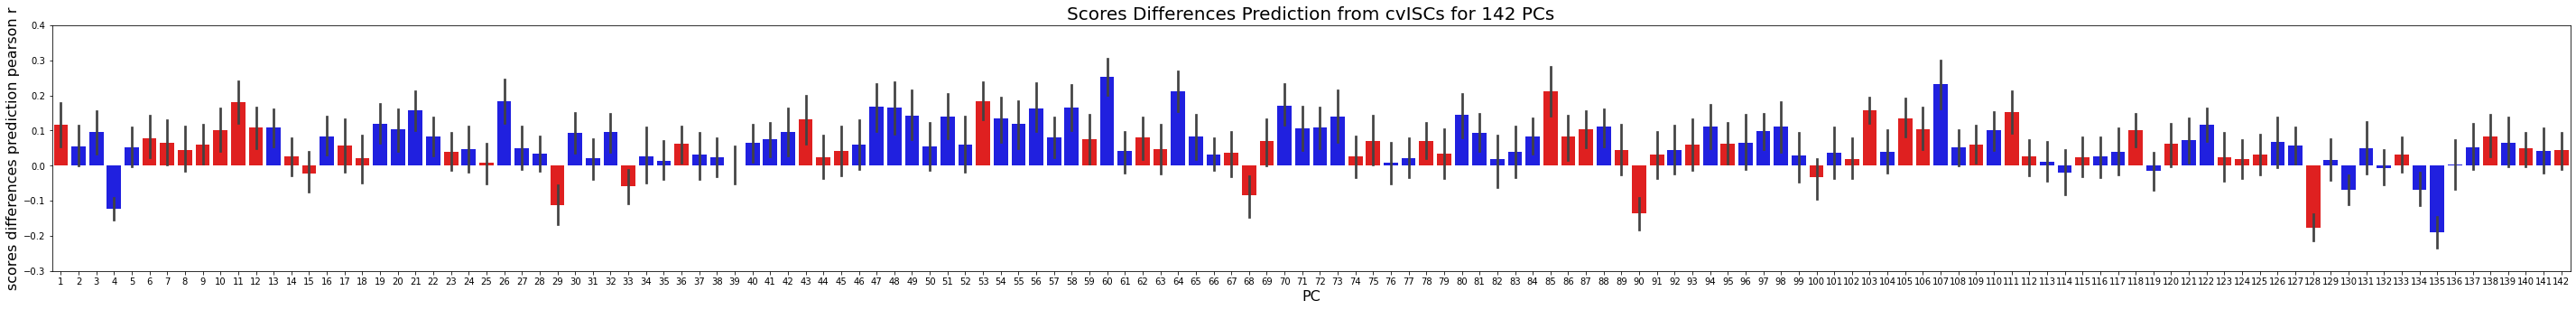

In [99]:
#cols = ['red' if np.mean(results_df_scores_diff[results_df_scores_diff['PC']==x]['scores diff coop']) < 0 else 'blue' for x in range(1,143)]
cols = ['red' if np.mean(results_df_scores_diff[results_df_scores_diff['PC']==x]['coef']) < 0
       else 'blue' for x in range(1,143)]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='scores diff coop', data=results_df_scores_diff, palette=cols)#color='gray')
ax.set_ylim(-.3, .4)
ax.set_title('Scores Differences Prediction from cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('scores differences prediction pearson r', fontsize=16);

### Multiple Regression
Wins multiple regression

In [67]:
#from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

results_wins_multi = np.full((n_maps), np.nan)   #n_repeats
pairs = [(0,1),(2,3)]
#for pair_id, pair in enumerate(pairs):
#    scores = []
for f, (train, test) in enumerate(cv3.split(cvISC_stack[0])): #enumerate(cv2.split()):
    # Initialize simple classifier
    clf = LogisticRegression(penalty='none', max_iter=300, class_weight='balanced') 

    # Z-score training cvISCs
    results_train = zscore(np.moveaxis(cvISC_stack[..., train],0,1))
    results_test = zscore(np.moveaxis(cvISC_stack[..., test],0,1))

    # Train on train cvISCs
    clf.fit(results_train, wins_stack[train])

    # Predict test cvISCs 
    pred = clf.predict(results_test)

    # Evaluate accuracy
    score = accuracy_score(wins_stack[test], pred)
    #scores.append(score)
    results_wins_multi[f] = score #np.array(scores)
print(f"Finished wins regression")

Finished wins regression


In [68]:
results_wins_multi.shape

(32,)

In [72]:
len(clf.coef_[0])

142

In [78]:
results_wins_multi

array([0.6875  , 0.65625 , 0.765625, 0.75    , 0.71875 , 0.78125 ,
       0.78125 , 0.796875, 0.703125, 0.6875  , 0.75    , 0.671875,
       0.734375, 0.703125, 0.6875  , 0.6875  , 0.6875  , 0.71875 ,
       0.71875 , 0.640625, 0.78125 , 0.71875 , 0.765625, 0.734375,
       0.734375, 0.640625, 0.625   , 0.796875, 0.671875, 0.65625 ,
       0.640625, 0.8125  ])

In [73]:
np.save('results_wins_multi.npy', results_wins_multi)

In [74]:
results_wins_multi = np.load('results_wins_multi.npy')

Bootstrap evaluation 

In [108]:
np.mean(results_wins_multi)

0.71728515625

In [13]:
results_wins_maps = np.mean(results_wins_multi, axis=0)

n_maps = 32
n_bootstraps = 10000

bootstrap_dist = []
for i in np.arange(n_bootstraps):
    bootstrap_dist.append(np.mean(np.random.choice(results_wins_maps, n_maps, replace=True)))

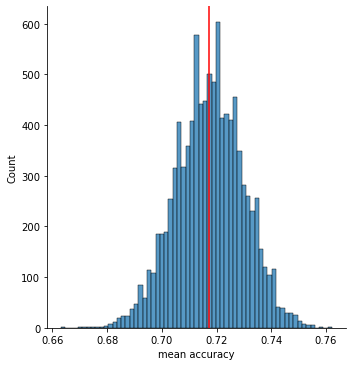

In [19]:
# bootstrap distribution and mean
sns.displot(bootstrap_dist)
plt.xlabel('mean accuracy')
plt.axvline(np.mean(results_wins_maps), c='r')

In [14]:
# 95% confidence range
np.percentile(bootstrap_dist, 2.5), np.percentile(bootstrap_dist, 97.5)

(0.69287109375, 0.74072265625)

In [23]:
# Correlation of prediction accuracies for the 2 teams on each map
from scipy.stats import pearsonr
pearsonr(results_wins_multi[0], results_wins_multi[1])

(0.4138404798528727, 0.018544740639397428)

Extract and plot the coefficients

In [109]:
wins_multi_coefs = clf.coef_

In [110]:
dict_wins_multi_coef = {'PC': [], 'coef': []}

for pc_id in np.arange(n_pcs): 
    dict_wins_multi_coef['coef'].append(wins_multi_coefs[0, pc_id])
    dict_wins_multi_coef['PC'].append(pc_id + 1)

df_wins_multi_coef = pd.DataFrame(dict_wins_multi_coef)

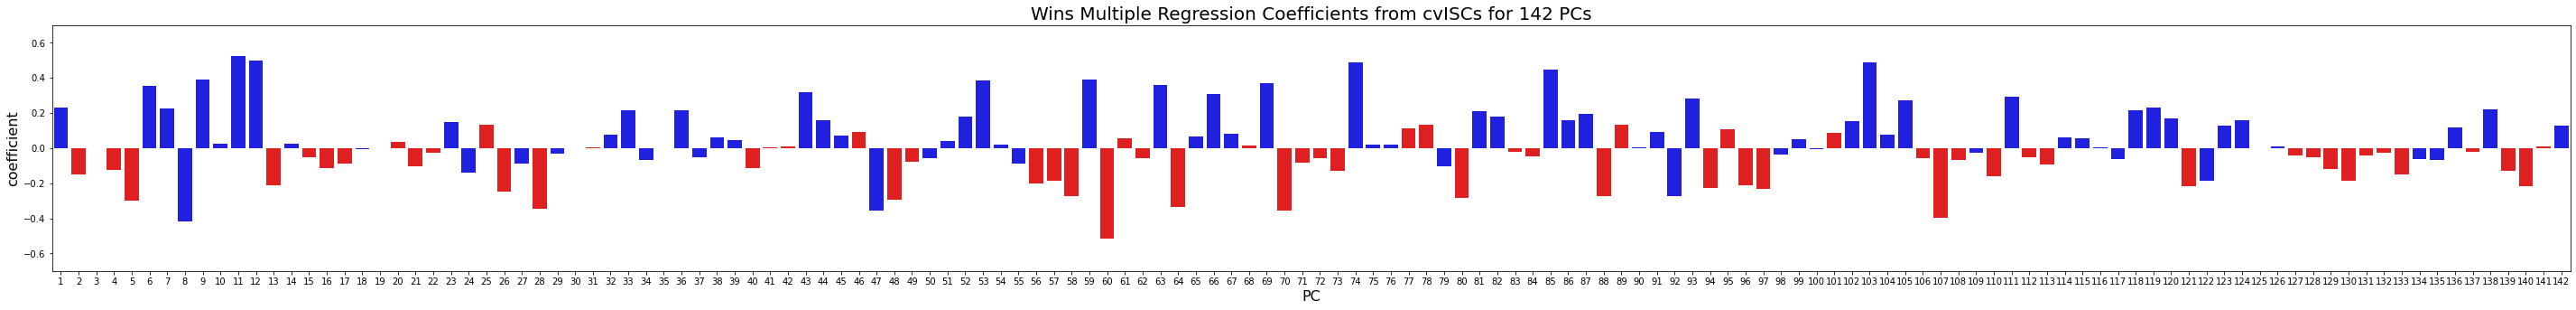

In [125]:
cols = ['red' if x < 0 else 'blue' for x in df_scores_multi_coef.coef]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='coef', data=df_wins_multi_coef, palette=cols) #color='gray')
ax.set_ylim(-0.7, 0.7)
ax.set_title('Wins Multiple Regression Coefficients from cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('coefficient', fontsize=16);

Scores multiple regression

In [75]:
#from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

results_scores_multi = np.full((n_maps), np.nan)   #n_repeats
pairs = [(0,1),(2,3)]
#for pair_id, pair in enumerate(pairs):
#    scores = []
for f, (train, test) in enumerate(cv3.split(cvISC_stack[0])): #enumerate(cv2.split()):
    # Initialize simple classifier
    clf = LinearRegression() 

    # Z-score training cvISCs
    results_train = zscore(np.moveaxis(cvISC_stack[..., train],0,1))
    results_test = zscore(np.moveaxis(cvISC_stack[..., test],0,1))

    # Train on train cvISCs
    clf.fit(results_train, scores_stack[train])

    # Predict test cvISCs 
    pred = clf.predict(results_test)

    # Evaluate accuracy
    r = pearsonr(pred, scores_stack[test])[0]
    #scores.append(r)
    results_scores_multi[f] = score #np.array(scores)
print(f"Finished scores regression")

Finished scores regression


In [76]:
results_scores_multi.shape

(32,)

In [77]:
np.save('results_scores_multi.npy', results_scores_multi)

Bootstrap evaluation

In [28]:
np.mean(results_scores_multi)

0.5626252269098615

In [29]:
results_scores_maps = np.mean(results_scores_multi, axis=0)

n_maps = 32
n_bootstraps = 10000

bootstrap_dist = []
for i in np.arange(n_bootstraps):
    bootstrap_dist.append(np.mean(np.random.choice(results_scores_maps, n_maps, replace=True)))

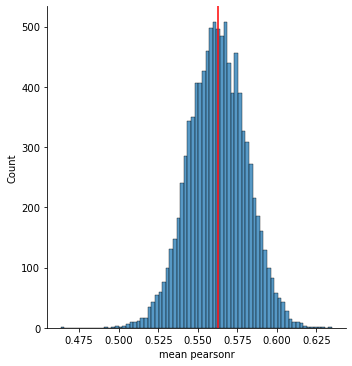

In [31]:
# bootstrap distribution and mean
sns.displot(bootstrap_dist)
plt.xlabel('mean pearsonr')
plt.axvline(np.mean(results_scores_maps), c='r')

In [32]:
# 95% confidence range
np.percentile(bootstrap_dist, 2.5), np.percentile(bootstrap_dist, 97.5)

(0.5267580410322992, 0.5977357125620031)

In [35]:
# Correlation of prediction pearsonr for the 2 teams on each map
from scipy.stats import pearsonr
pearsonr(results_scores_multi[0], results_scores_multi[1])

(0.4762552721024862, 0.005861201938305223)

Extract and plot the coefficients

In [93]:
scores_multi_coefs = clf.coef_
scores_multi_coefs.shape

(142,)

In [94]:
dict_scores_multi_coef = {'PC': [], 'coef': []}

for pc_id in np.arange(n_pcs): 
    dict_scores_multi_coef['coef'].append(scores_multi_coefs[pc_id])
    dict_scores_multi_coef['PC'].append(pc_id + 1)

df_scores_multi_coef = pd.DataFrame(dict_scores_multi_coef)

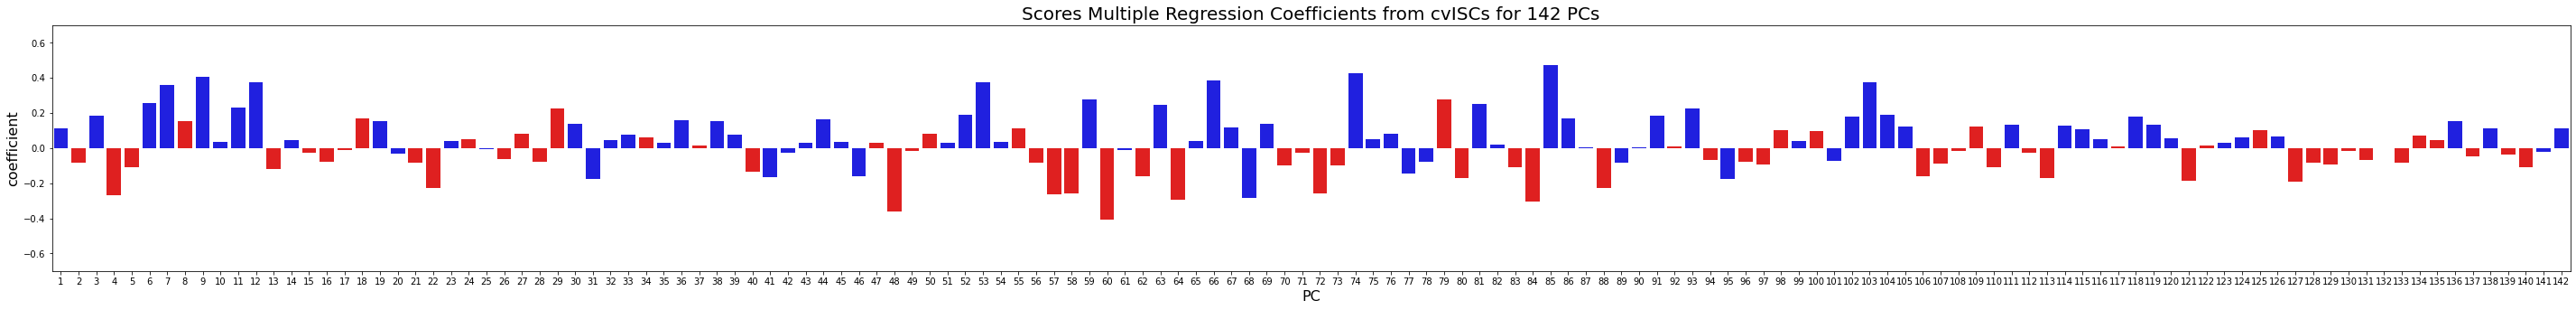

In [127]:
cols = ['red' if x < 0 else 'blue' for x in df_wins_multi_coef.coef]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='coef', data=df_scores_multi_coef, palette=cols)# color='gray')
ax.set_ylim(-0.7, 0.7)
ax.set_title('Scores Multiple Regression Coefficients from cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('coefficient', fontsize=16);

Score differences multiple regression

In [71]:
#from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

results_score_diffs_multi = np.full((n_maps), np.nan)   #n_repeats
scores=[]
for f, (train, test) in enumerate(cv2.split()):
    # Initialize simple classifier
    clf = LinearRegression() 

    # Z-score training cvISCs
    results_train = zscore(np.moveaxis(results[..., 0, train]-results[..., 5, train],0,1)) 
    results_test = zscore(np.moveaxis(results[..., 0, train]-results[..., 5, train],0,1))

    # Train on train cvISCs
    clf.fit(results_train, scores_stack[train, 0]-scores_stack[train, 1])

    # Predict test cvISCs 
    pred = clf.predict(results_test)

    # Evaluate accuracy
    r = pearsonr(pred, scores_stack[train, 0]-scores_stack[train, 1])[0]
    scores.append(r)
results_score_diffs_multi = np.array(scores)
print(f"Finished scores regression")

Finished scores regression


In [72]:
results_score_diffs_multi.shape

(32,)

Bootstrap evaluation

In [73]:
np.mean(results_score_diffs_multi)

0.7275004457279404

In [74]:
#results_scores_maps = results_score_diffs_multi

n_maps = 32
n_bootstraps = 10000

bootstrap_dist = []
for i in np.arange(n_bootstraps):
    bootstrap_dist.append(np.mean(np.random.choice(results_score_diffs_multi, n_maps, replace=True)))

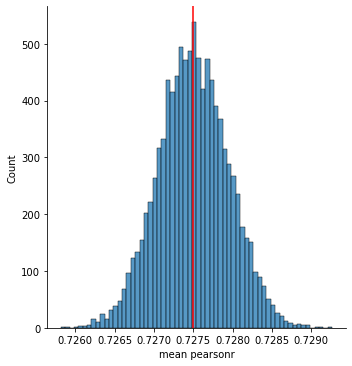

In [75]:
# bootstrap distribution and mean
sns.displot(bootstrap_dist)
plt.xlabel('mean pearsonr')
plt.axvline(np.mean(results_score_diffs_multi), c='r')

In [76]:
# 95% confidence range
np.percentile(bootstrap_dist, 2.5), np.percentile(bootstrap_dist, 97.5)

(0.7266427505025734, 0.7283770354564391)

Extract and plot the coefficients

In [77]:
score_diffs_multi_coefs = clf.coef_
score_diffs_multi_coefs.shape

(142,)

In [78]:
dict_score_diffs_multi_coef = {'PC': [], 'coef': []}

for pc_id in np.arange(n_pcs): 
    dict_score_diffs_multi_coef['coef'].append(score_diffs_multi_coefs[pc_id])
    dict_score_diffs_multi_coef['PC'].append(pc_id + 1)

df_score_diffs_multi_coef = pd.DataFrame(dict_score_diffs_multi_coef)

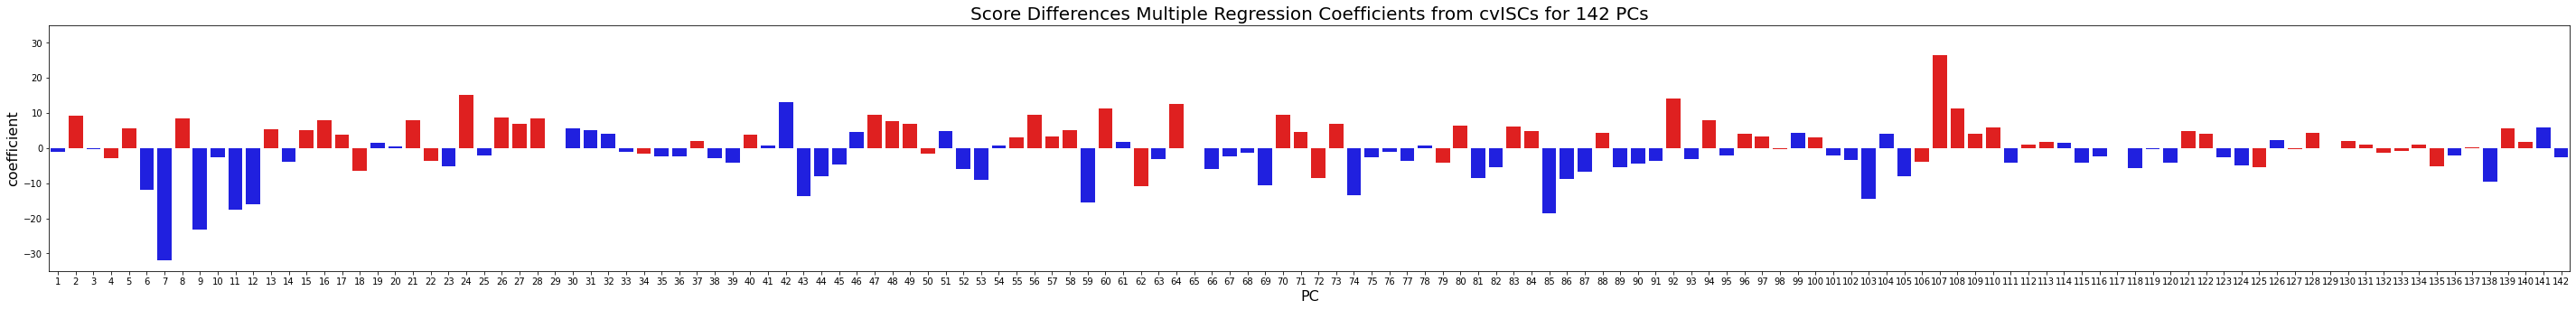

In [128]:
cols = ['red' if x < 0 else 'blue' for x in df_wins_multi_coef.coef]
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='coef', data=df_score_diffs_multi_coef, palette=cols)#color='gray')
ax.set_ylim(-35, 35)
ax.set_title('Score Differences Multiple Regression Coefficients from cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('coefficient', fontsize=16);